In [1]:
import scanpy as sc
from itertools import combinations
from scipy.spatial.distance import cdist
from analysis_utils import *


In [2]:
def load_my_data(cell_meta_f, tx_meta_f, adata_f, mistic_path, custome_t_idx = 0, tag="mistic"):
    cell_meta = pd.read_csv(cell_meta_f)
    tx_meta = read_parquet(tx_meta_f).set_index('transcript_id')
    pre = sc.read_h5ad(adata_f)
    tx_remove = pd.read_parquet(mistic_path + f'/{tag}_tx_to_remove.parquet')
    tx_reassignment = pd.read_parquet(mistic_path + f'/{tag}_tx_to_reassign.parquet')
    #reassignment = pd.read_csv(mistic_path + '/reassignment.csv', index_col=1)
    #resovi_post = sc.read_h5ad(mistic_path + '/supervised_resolvi.h5ad')
    mistic_t = pd.read_csv(mistic_path + f'/{tag}_criteria_df.csv')
    tx_meta.rename(
        columns = {
            'x_location':'global_x',
            'y_location':'global_y',
            'feature_name':'gene',
            },
        inplace=True
    )
    tx_meta = tx_meta[['global_x','global_y', 'gene','cell_id']]
    cell_meta.rename(
        columns = {
            'x_centroid':'center_x',
            'y_centroid':'center_y',
            },
        inplace=True
    )
    cell_meta = cell_meta[['center_x','center_y', 'leiden']]
    tx_meta.index = ['tx_' + str(i) for i in range(len(tx_meta))]
    tx_meta = tx_meta[tx_meta.cell_id.isin(pre.obs_names)]
    # load resolVI
    #resovi_post.X = resovi_post.layers['generated_expression']
    #resovi_post.layers['counts'] = resovi_post.X.copy()
    # Generate misc corrected counts
    post = pre.copy()
    tx_info = tx_meta.copy()
    tx_info = tx_info.drop(tx_remove.molecule_id.values)
    tx_info.loc[tx_reassignment.molecule_id, 'cell_id'] = tx_reassignment.to_cell_id.values
    corrected_counts = tx_info.groupby(['cell_id','gene']).count().iloc[:,0].reset_index()
    corrected_counts = corrected_counts.pivot(
        index='cell_id', columns='gene', values=corrected_counts.columns[2]).fillna(0)
    cm_cells = [x for x in corrected_counts.index if x in post.obs_names]
    post = post[cm_cells]
    post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
    post.layers['counts'] = post.X

    # correction to match resolVI level of TX removal
    reassign_t = mistic_t.iloc[custome_t_idx,0]
    remove_t = mistic_t.iloc[custome_t_idx,4]
    print('Custom cutoffs for reassignment: {:.2f}, removal: {:.2f}'.format(reassign_t, remove_t))
    #reassign_tx = reassignment[reassignment.reassign_probs>=reassign_t].copy()
    #remove_tx = reassignment.loc[
    #    (reassignment.reassign_probs<reassign_t) & 
    #    (reassignment.reassign_probs>=remove_t)
    #    ].index
    #tx_info = tx_meta.drop(remove_tx).copy()
    #tx_info.loc[reassign_tx.index,'cell_id'] = reassign_tx.neighbor_cell_id.values
    corrected_counts2 = tx_info.groupby(['cell_id','gene']).count().iloc[:,0].reset_index()
    corrected_counts2 = corrected_counts2.pivot(
        index='cell_id', columns='gene', values=corrected_counts2.columns[2]).fillna(0)
    #post2 = pre[corrected_counts2.index].copy()
    #post2.X = corrected_counts2.loc[post2.obs_names, post2.var_names].values
    #post2.layers['counts'] = post2.X
    return pre, post , tx_meta, tx_reassignment, tx_remove #, reassignment



In [3]:
mistic_path = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_luad_results/oops/original"
cell_meta_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/processed_cell_metadata_reindexed.csv"
tx_meta_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/process_tx_meta_filtered_filtered.parquet"
adata_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/processed_adata.h5ad"
input_path = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_luad_results/oops/original"

In [4]:
pre, post, tx_meta, tx_reassignment, tx_remove = load_my_data(cell_meta_f, tx_meta_f, adata_f, mistic_path, custome_t_idx = 0)

/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_3128837/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_3128837/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.20, removal: 0.20


In [5]:
mistic_path2 = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_luad_results/oops/nospatial"
pre, post_a , tx_meta, tx_reassignment, tx_remove = load_my_data(cell_meta_f, tx_meta_f, adata_f, mistic_path2, custome_t_idx = 0, tag="mistica")

/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_3128837/4231015519.py:42: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  post.X = corrected_counts.astype(int).loc[cm_cells, post.var_names].values
/home/jholz/miniconda3/envs/mistic2/lib/python3.11/site-packages/scipy/sparse/_index.py:207: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)
/tmp/ipykernel_3128837/4231015519.py:43: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  post.layers['counts'] = post.X


Custom cutoffs for reassignment: 0.50, removal: 0.50


In [6]:
cts = ['T_cell', 'Endothelial_cell','Macrophage', 'Tumor_cell', 'Fibroblast']
me_genes = {
    'Endothelial_cell': ['VWF','EGFL7','CLEC14A','ECSCR','CD34'],
    'B_cell': ['CD79A','MS4A1', 'BANK1', 'MZB1', 'CD19'],
    'Fibroblast': ['FBLN1','ACTA2','PCOLCE','THY1','FBN1'],
    'Macrophage': ['AIF1', 'CD68', 'FCGR3A', 'MS4A6A', 'MRC1'],
    'T_cell': ['CCL5','TRAC','CD3D','CD3E','GZMA'],
    'Tumor_cell': ['KRT7', 'SFTA2', 'AGR3', 'EPCAM', 'GPRC5A'],
}
ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'}

In [7]:
me_genes_filtered = {}
for cell_type, genes in me_genes.items():
    valid = [g for g in genes if g in pre.var_names]
    missing = set(genes) - set(valid)
    if missing:
        print(f"[{cell_type}] missing from dataset: {missing}")
    if valid:
        me_genes_filtered[cell_type] = valid

print(f"\nUsing {sum(len(v) for v in me_genes_filtered.values())} / "
      f"{sum(len(v) for v in me_genes.values())} marker genes total\n")

[Endothelial_cell] missing from dataset: {'VWF'}
[Fibroblast] missing from dataset: {'FBN1', 'FBLN1'}
[Macrophage] missing from dataset: {'MRC1'}
[T_cell] missing from dataset: {'TRAC'}
[Tumor_cell] missing from dataset: {'AGR3', 'KRT7', 'SFTA2'}

Using 22 / 30 marker genes total



In [8]:
adata_raw = sc.read_10x_h5("/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_data/cell_feature_matrix.h5")  # or .read_mtx / read_csv

# Align barcodes (in case of subsetting)
common_obs = pre.obs_names.intersection(adata_raw.obs_names)
pre.layers["counts"] = adata_raw[common_obs, pre.var_names].X.copy()
pre.X = adata_raw[common_obs, pre.var_names].X.copy()

In [9]:
resolvi_f = "/orcd/compute/edsun/001/jholz/mistic/mistic_bayesian/figure_3_luad_results/resolvi.h5ad"
adata_resolvi = sc.read_h5ad(resolvi_f)

In [14]:
adata_resolvi.X = adata_resolvi.layers['generated_expression']
adata_resolvi.layers['counts'] = adata_resolvi.X.copy()

In [15]:
resovi_post_round = adata_resolvi.copy()
tmp = resovi_post_round.layers['generated_expression']
tmp[tmp<0.1] = 0
adata_resolvi.layers['counts'] = tmp

In [13]:
print(adata_resolvi.layers["generated_expression"])

[[1.1314199e+01 2.4775051e-02 1.2220389e+00 ... 1.3356708e-01
  7.4886549e-01 4.1265961e-02]
 [5.1298041e+00 3.9207749e-03 6.9880712e-01 ... 6.6957980e-02
  4.3567756e-01 6.1935140e-03]
 [1.6284580e+00 4.1571952e-02 4.2653441e-01 ... 1.5395018e-01
  2.3301849e+00 9.7013786e-03]
 ...
 [1.0846153e+00 9.2737190e-03 8.6207426e-01 ... 1.1657046e-01
  7.3008740e-01 6.2579373e-03]
 [1.5006044e+00 5.7741264e-03 4.1891819e-01 ... 8.9101642e-02
  5.1405406e-01 4.1616694e-03]
 [1.0667152e+00 6.2393071e-03 3.2279876e-01 ... 9.6720174e-02
  5.0267065e-01 7.9550724e-03]]


In [16]:
def my_me_exp_plot(
        cts, 
        me_genes, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisC','ResolVI','MisC_overcorrection']):
    res = []
    for i, _adata in enumerate(adatas):
        _adata = _adata.copy()
        _adata.X = _adata.layers['counts']
        sc.pp.normalize_total(_adata)
        sc.pp.log1p(_adata)
        df_exp = _adata.to_df()
        # df_exp = (df_exp>df_exp.quantile(0.05)) + 0
        if ct_col not in _adata.obs.columns:
            ct_col = 'leiden'
        ctype = _adata.obs[ct_col].astype(str)
        ctype = ctype.astype(str).replace(ct_rename_dict)
        cosine_dist = pd.DataFrame(index=cts, columns=cts)
        idx = []
        cosine_dist = []
        for g,c in combinations(cts,2):
            c_genes = me_genes[c]
            g_genes = me_genes[g]
            _df = df_exp[ctype.isin(cts)]
            base_exp = _df[c_genes].sum(axis=1)
            me_exp = _df[g_genes].sum(axis=1)
            cs = 1 - cdist(base_exp.values.reshape(1,-1), me_exp.values.reshape(1,-1), metric='cosine')[0,0]
            idx.append('-'.join(sorted([g,c])))
            cosine_dist.append(cs)
        tmp = pd.DataFrame(cosine_dist, index=idx, columns = ['CS']).sort_index()
        tmp['Preprocessing'] = labels[i]
        res.append(tmp)
    res = pd.concat(res)
    res = res.reset_index()
    res.columns = ['ME_group', 'CS', 'Preprocessing']
    sns.barplot(data = res, x = 'ME_group', y= 'CS', hue = 'Preprocessing')
    plt.xticks(rotation=90)
    # plt.savefig(output_path + '/ME_exp_comparison.pdf', bbox_inches='tight')

In [ ]:
adatas = [pre, post]
my_me_exp_plot(
        cts, 
        me_genes_filtered, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisTIC'])

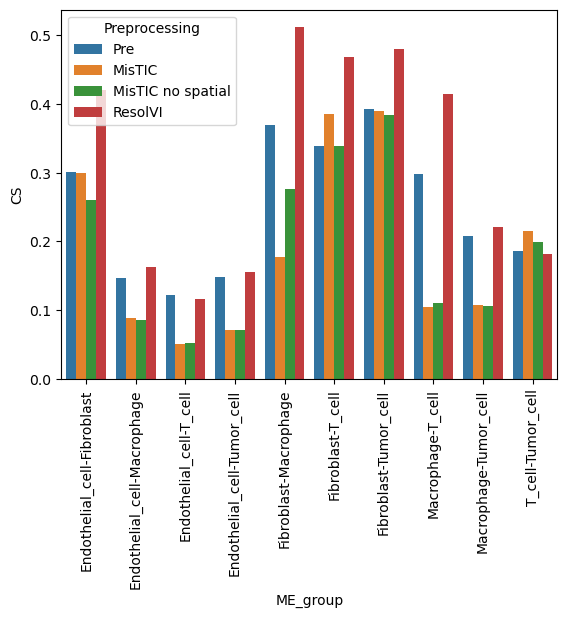

In [17]:
adatas = [pre, post, post_a, adata_resolvi]
my_me_exp_plot(
        cts, 
        me_genes_filtered, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisTIC', 'MisTIC no spatial', "ResolVI"])

AnnData object with n_obs × n_vars = 156230 × 480
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'leiden', 'leiden_sub', 'score_Endothelial_cell', 'score_B_cell', 'score_Fibroblast', 'score_Macrophage', 'score_T_cell', 'score_Tumor', 'leiden_rescored'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'leiden', 'leiden_colors', 'leiden_rescored_colors', 'leiden_sub', 'leiden_sub_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 11964573 stored elements and shape (156230, 480)>
  Coords	Values
  (0, 0)	7.0
  (0, 5)	1.0
  (0, 15)	1.0
  (0, 16)	1.0
  (0, 25)	1.0
  (0, 36)	1.0
  (0, 83)	1.0
  (0, 90)	1.0
  (0, 101)	1.0
  (0, 106)	1.0
  (0, 122)	1.0
  (0, 141)	1.0
  (0, 170)	1.0
  (0, 181)	1.0
  (0, 211)	3.0
  (0, 214)	1.0
  (0, 260)	1.0
  (0, 272)	1.0
  (0, 274)	1.0
  (0, 283)	1.0
  (0, 289)	1.0
  (0, 296)	2.0
  (0, 302)	1.0
  (0, 304)	5.0
  (0, 317)	2.0
  :	:
  (156229, 279)	2.0
  (156229, 286)	2.0
  (156229, 306)	1.0
  (156229, 313)	2.0
  (156229, 318)	1.0
  (156229, 339)	1.0
  (156229, 345)	2.0
  (156229, 349)	2.0
  (156229, 357)	2.0
  (156229, 359)	1.0
  (156229, 361)	1.0
  (156229, 364)	1.0
  (156229, 380)	2.0
  (156229, 392)	2.0
  (156229, 404)	1.0
  (156229, 405)	1.0
  (156229, 414)	1.0
  (156229, 427)	1.0
  (156229, 428)	1.0
  (156229, 429)	1.0
  (156229, 434)	2.0
  (156229, 439)	1.0
  (156229, 453)	1.0
  (156229, 460)	2.0
  (156229, 475)	1.0
<

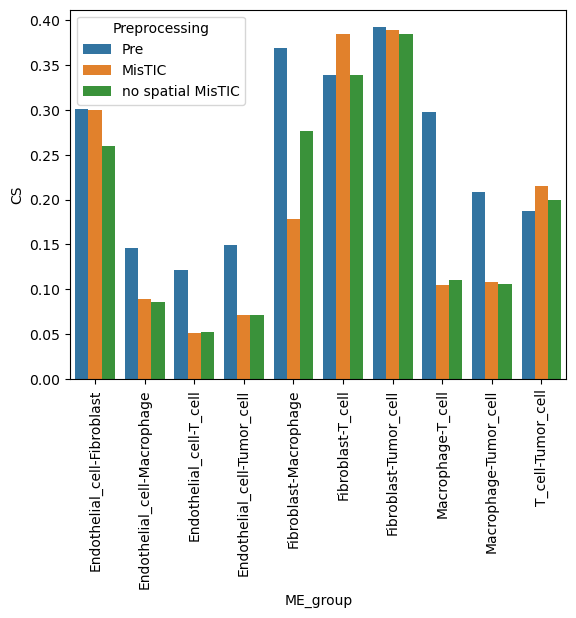

In [70]:
adatas = [pre, post, post_a]
my_me_exp_plot(
        cts, 
        me_genes_filtered, 
        adatas,
        ct_rename_dict = {
                'Tumor':'Tumor_cell',
                'Fibroblst':'Fibroblast'},
        ct_col = 'leiden',
        labels = ['Pre','MisTIC', 'no spatial MisTIC'])